In [2]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
from twfv import run_em_like
from twfv.simulate import simulate_factor_data_bspline
from twfv.cp import NaiveAbsoluteResidualCP, unflatten


def flatten(i: int, j: int, t: int, I: int, J: int, T: int) -> int:
    return i * (J * T) + j * T + t

In [3]:
def local_var_Y_from_info(info):
    """
    Compute per-subject/time/channel innovation variance:
      Var[epsilon_{i,t,j}] = kappa_i * sum_k X_{j,k}^2 * a2_{i,t,k} + s_i^2 * Psi_j

    Returns:
        var: array (I, T, J)
    """
    X = np.asarray(info["X_true"], dtype=float)          # (J, r)
    Psi = np.asarray(info["Psi_true"], dtype=float)      # (J,)
    s = np.asarray(info["s_true"], dtype=float)          # (I,)
    kappa = np.asarray(info["kappa_true"], dtype=float)  # (I,)
    a2 = np.asarray(info["a2_true"], dtype=float)        # (I, T, r) or (T, r)

    if a2.ndim == 2:  # allow (T, r) broadcast to subjects
        a2 = a2[None, ...]

    Xsq = X ** 2                     # (J, r)
    print(Xsq)
    base = np.einsum("itr,jr->itj", a2, Xsq)  # sum_k X_{j,k}^2 * a2_{i,t,k}, shape (I, T, J)
    print(np.cov(a2[0,:,0],a2[0,:,1]))
    print(a2[0,:30,0])
    print(base[0,:30,0])
    print(base[0,:30,0]*kappa[0])
    print(s[0]**2*Psi[0])
    var = kappa[:, None, None] * base + (s ** 2)[:, None, None] * Psi[None, None, :]
    print(var[0,:30,0])
    return var  # (I, T, J)

In [18]:
I, T, J, r, M_ctrl = 10, 100, 5, 2, 10
rng = np.random.default_rng(1)
kappa_true = np.exp(rng.normal(2, .5, size=I))
C_true=rng.normal(scale=3, size=(I, r, M_ctrl))
miss_prob_per_channel=np.linspace(0.1,0.3,J)
Y, M, info = simulate_factor_data_bspline(
    I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,miss_prob_per_channel=miss_prob_per_channel,kappa_true=kappa_true,C_true=C_true
)
# Y, M, info = simulate_factor_data_bspline(
#     I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,kappa_true=kappa_true,C_true=C_true
# )
local_var_Y=local_var_Y_from_info(info)

[[0.34231833 0.60003552]
 [0.32785311 1.10836175]
 [1.09588937 0.31120189]
 [0.55196603 0.40410339]
 [0.3608928  0.2208153 ]]
[[ 1.11074642 -0.40353253]
 [-0.40353253  4.1979606 ]]
[2.29716414 2.75592425 3.10321121 3.22952828 3.07321076 2.76127409
 2.32413605 1.78599992 1.34926997 1.00517095 0.77354157 0.62707819
 0.52835157 0.47644681 0.45670525 0.45778252 0.47717908 0.50941533
 0.55299188 0.60019526 0.64002513 0.66099901 0.66470258 0.64827842
 0.64269408 0.69093519 0.86707639 1.25326367 1.96815589 2.9572595 ]
[1.01267813 1.15554598 1.27680136 1.33808593 1.3231485  1.28953338
 1.25401398 1.26435668 1.41689905 1.74162178 2.32675696 3.12362205
 4.11731934 5.01437797 5.67733464 5.89671317 5.47554738 4.54479916
 3.32415033 2.20787171 1.32928394 0.74685243 0.44452149 0.31139357
 0.25234159 0.24910686 0.30204638 0.43134942 0.67488298 1.01295041]
[ 8.8941213  10.14889711 11.21385546 11.75210386 11.62091187 11.32567794
 11.0137191  11.10455671 12.44430154 15.29626729 20.43537634 27.43406085
 

In [16]:
local_var_Y.round(3)[0, :, 0]

array([ 4.567,  8.377, 12.847, 17.56 , 20.878, 21.441, 19.121, 14.971,
       10.768,  7.47 ,  5.082,  3.657,  2.836,  2.466,  2.333,  2.4  ,
        2.661,  3.142,  3.931,  5.032,  6.54 ,  8.503, 10.818, 13.213,
       15.996, 18.501, 20.588, 22.044, 22.602, 21.948, 20.4  , 18.078,
       15.788, 13.21 , 10.716,  8.702,  7.074,  5.703,  4.613,  3.787,
        3.123,  2.685,  2.373,  2.136,  1.969,  1.848,  1.768,  1.729,
        1.631,  1.598,  1.612,  1.648,  1.722,  1.814,  1.946,  2.089,
        2.204,  2.349,  2.572,  2.734,  2.849,  2.981,  3.112,  3.244,
        3.38 ,  3.486,  3.559,  3.595,  3.694,  3.697,  3.718,  3.733,
        3.74 ,  3.761,  3.777,  3.844,  3.847,  3.901,  3.993,  4.052,
        4.055,  4.083,  4.279,  4.391,  4.503,  4.704,  4.934,  5.316,
        5.719,  6.211,  6.76 ,  7.648,  8.541, 10.084, 12.419, 14.675,
       17.308, 22.672, 32.391, 43.678])

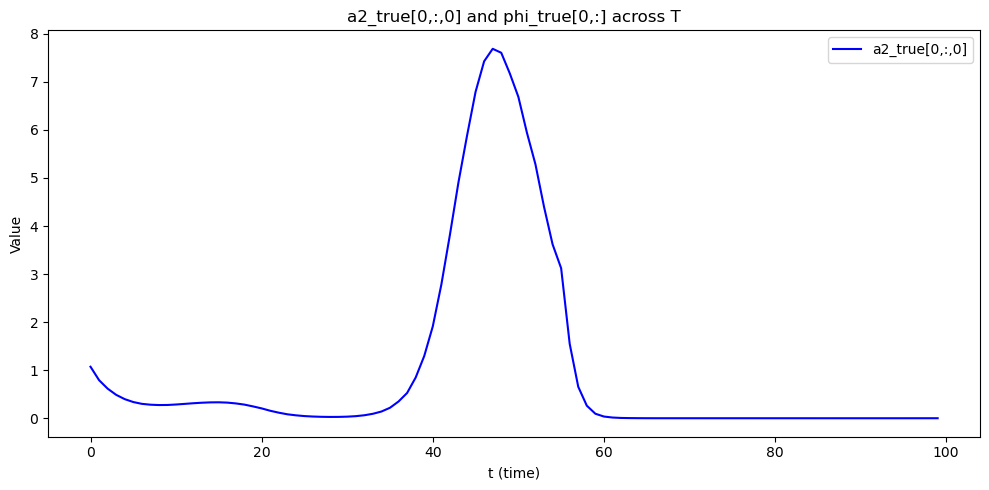

In [26]:
a2_true=info['a2_true']

T_range = np.arange(T)
plt.figure(figsize=(10, 5))
plt.plot(T_range, a2_true[0, :, 1], label='a2_true[0,:,0]', color='blue')
plt.xlabel('t (time)')
plt.ylabel('Value')
plt.title('a2_true[0,:,0] and phi_true[0,:] across T')
plt.legend()
plt.tight_layout()
plt.show()

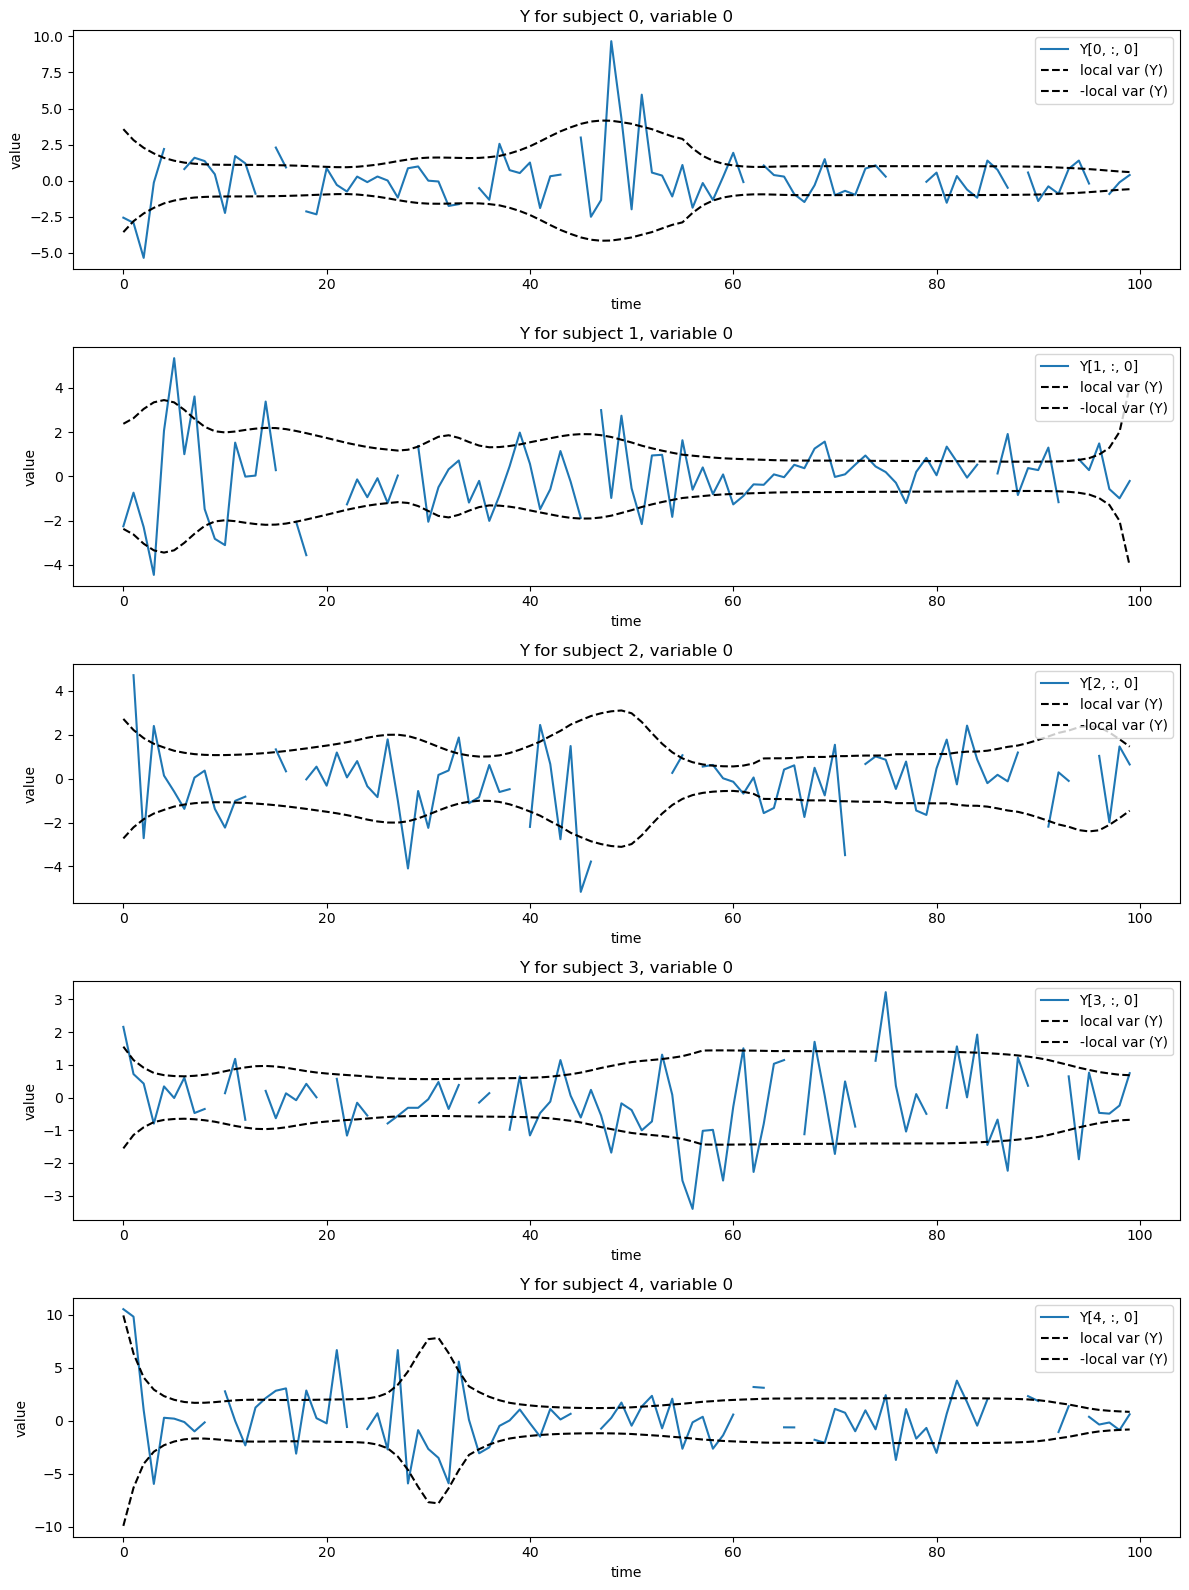

In [27]:

import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i, :, 0], label=f"Y[{i}, :, 0]")
    var = local_var_Y[i, :, 0]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for subject {i}, variable 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()


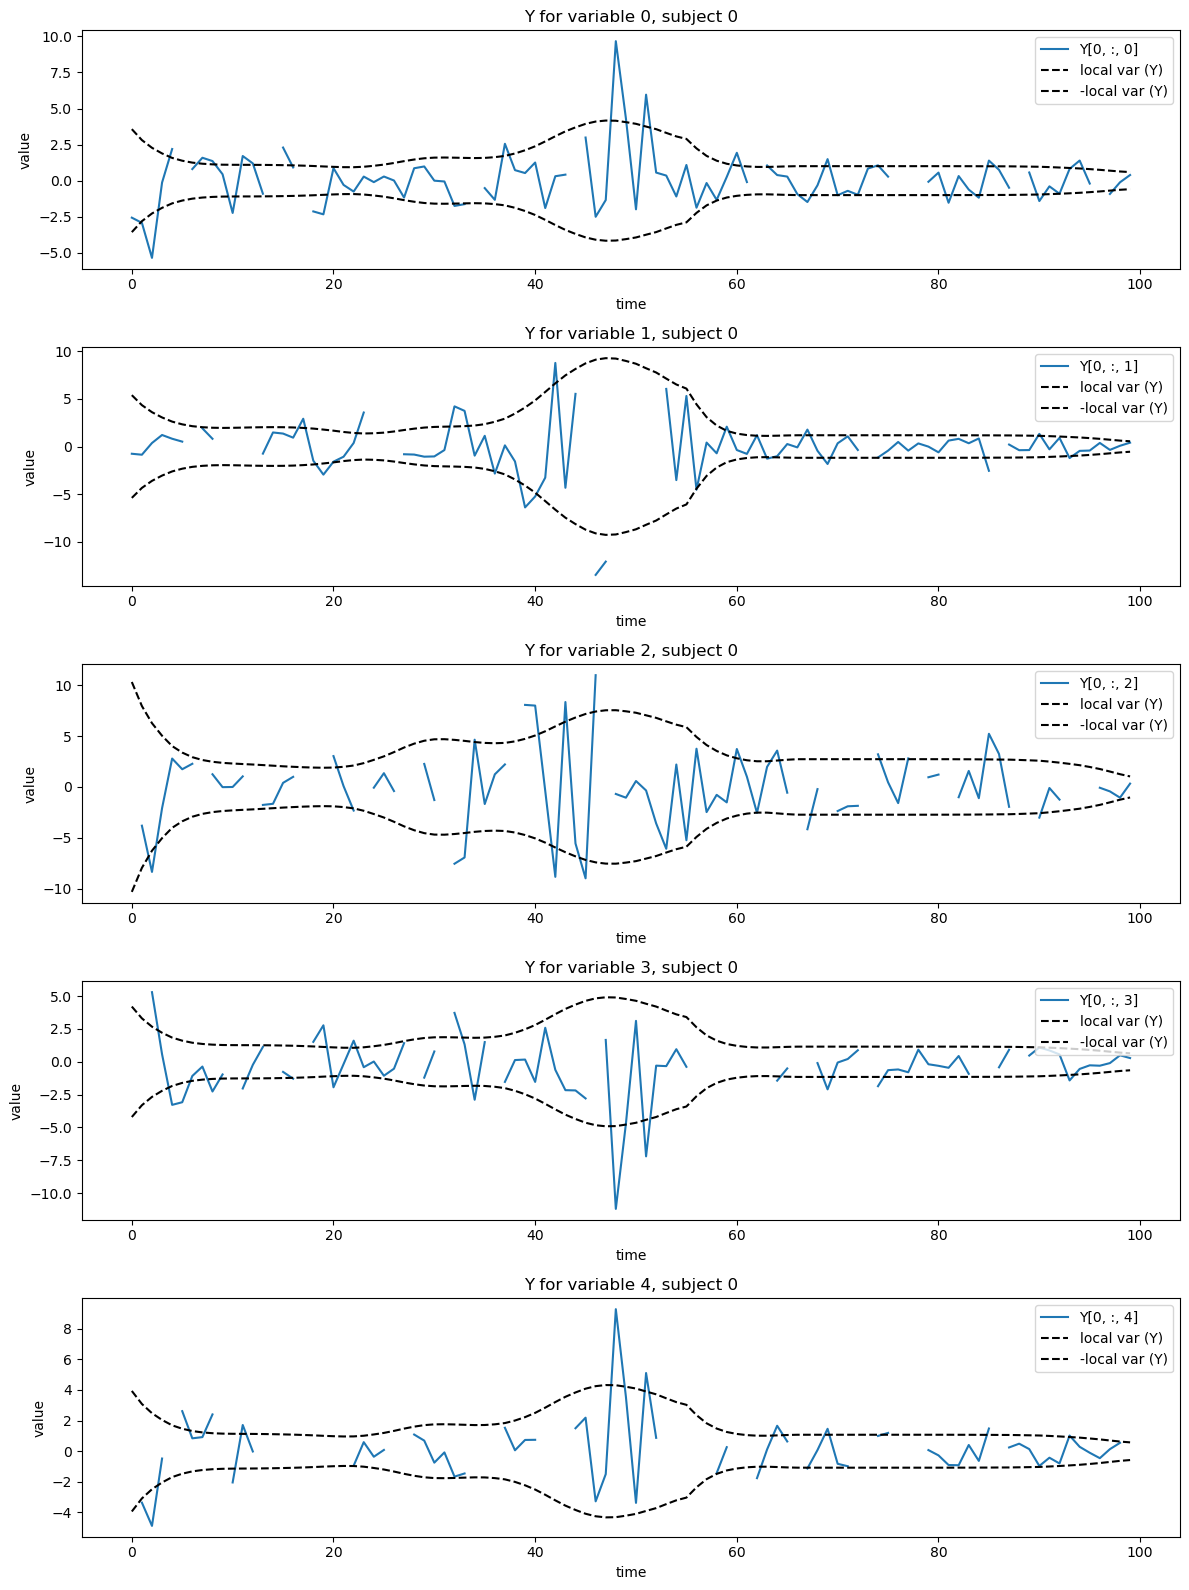

In [28]:
import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_Y[0, :, j]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

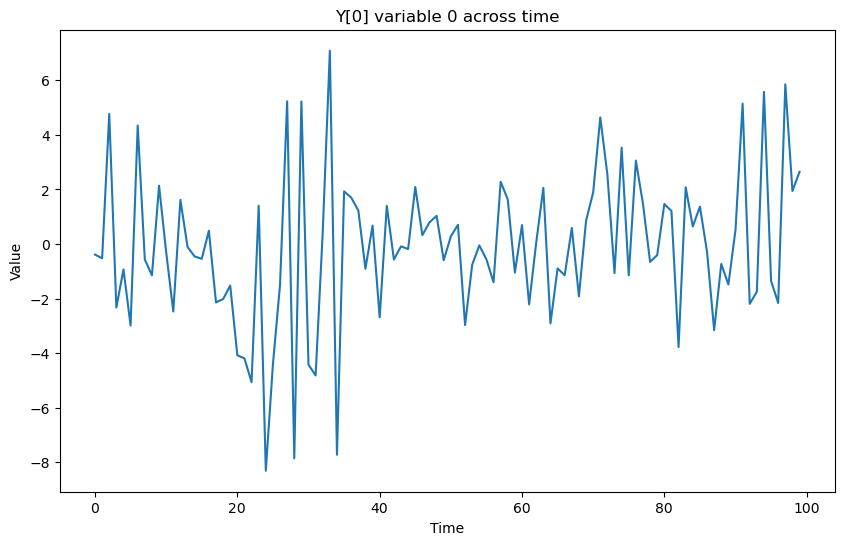

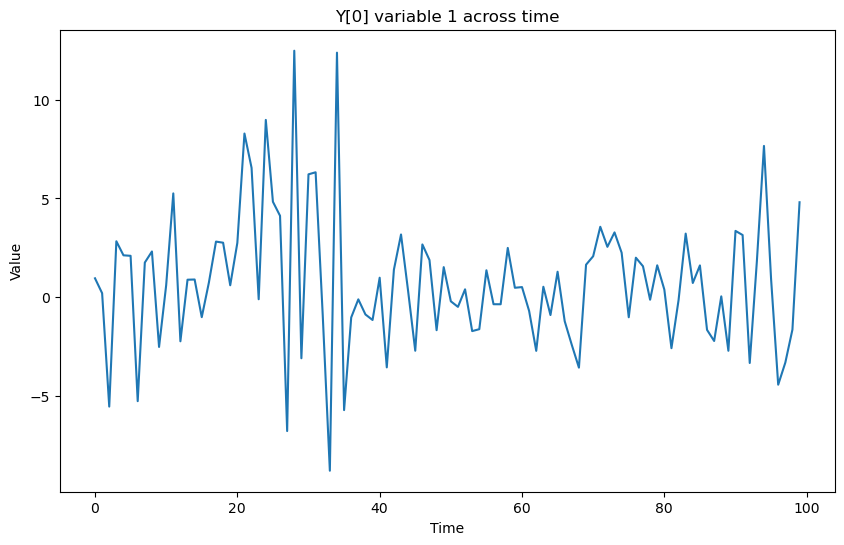

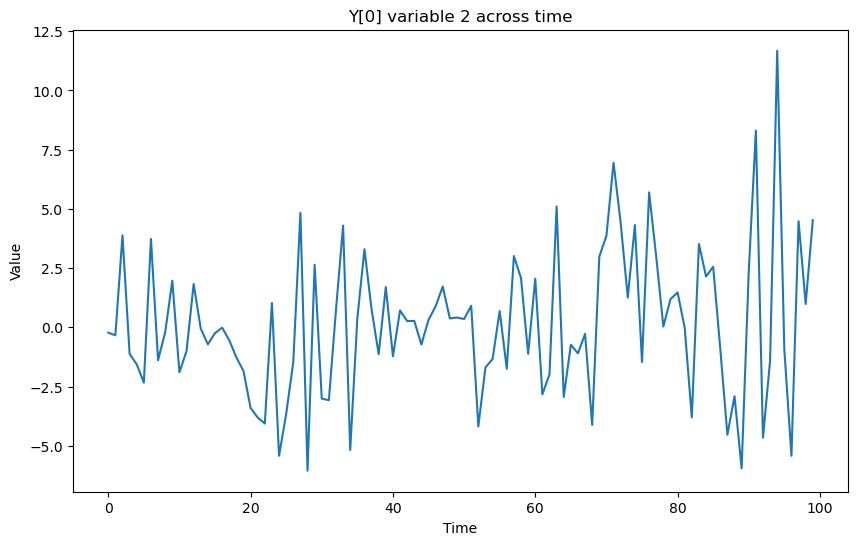

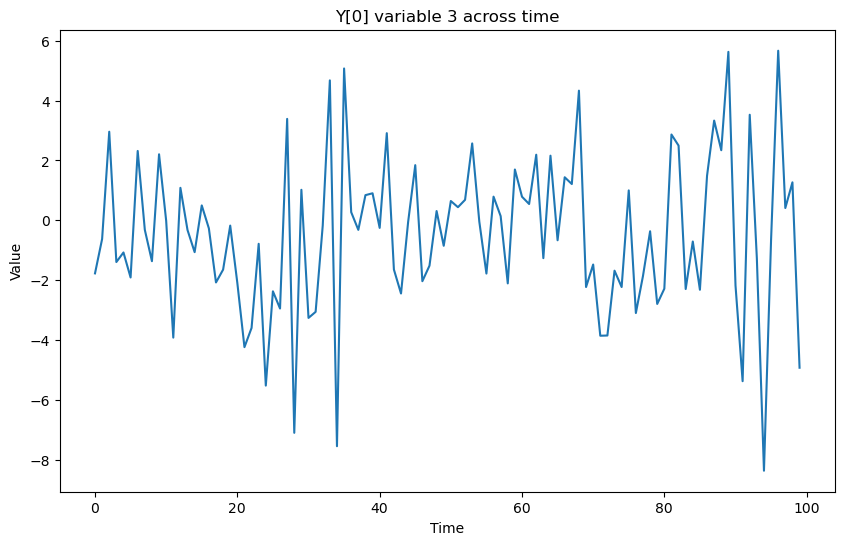

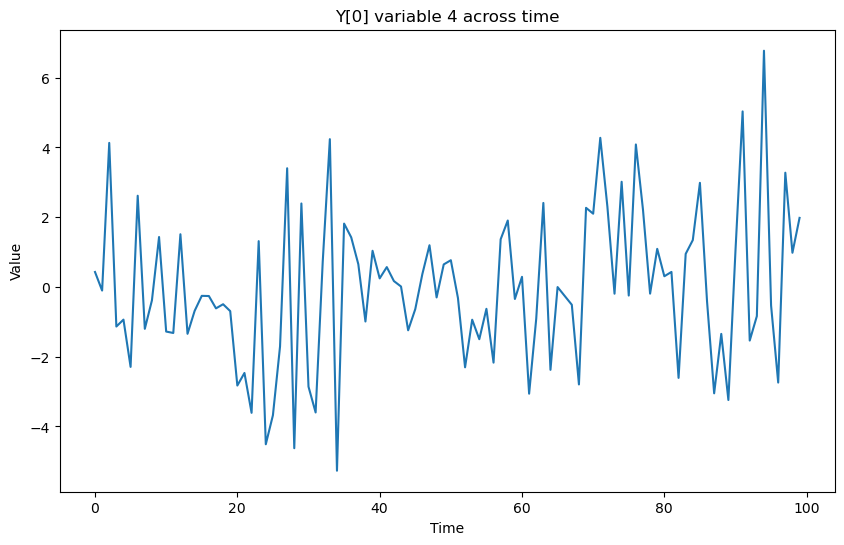

In [10]:
import matplotlib.pyplot as plt

# Plot each variable (channel) of Y[0] across time
for j in range(Y.shape[2]):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(Y.shape[1]), Y[0, :, j])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f'Y[0] variable {j} across time')
    plt.show()

In [19]:
# --- 2) Build indices ---
obs_idx_list = []
test_idx_list = []
for i in range(I):
    for t in range(T):
        for j in range(J):
            k = flatten(i, j, t, I, J, T)
            if M[i, t, j]:
                obs_idx_list.append(k)
            else:
                test_idx_list.append(k)
obs_idx = np.array(obs_idx_list, dtype=int)
test_idx = np.array(test_idx_list, dtype=int)

# Shuffle observed indices and split into train/cal
rng = np.random.default_rng(123)
rng.shuffle(obs_idx)
split = int(0.7 * obs_idx.size)
train_idx = obs_idx[:split]
cal_idx = obs_idx[split:]

# --- 3) Simple mean predictor (per-channel mean over train observed) ---
channel_sums = np.zeros(J, dtype=float)
channel_counts = np.zeros(J, dtype=float)
for k in train_idx:
    i, j, t = unflatten(int(k), I, J, T)
    channel_sums[j] += Y[i, t, j]
    channel_counts[j] += 1.0
channel_means = channel_sums / np.clip(channel_counts, 1.0, None)

In [20]:
# Calibration true and fitted
Y_cal_true = np.zeros(cal_idx.size, dtype=float)
for n, k in enumerate(cal_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_cal_true[n] = Y[i, t, j]
Y_test_true = np.zeros(test_idx.size, dtype=float)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_test_true[n] = Y[i, t, j]

Y_cal_fit = np.zeros(cal_idx.size, dtype=float)
Y_test_fit = np.zeros(test_idx.size, dtype=float)

In [21]:
from torch._C import device
degree: int = 3
max_outer: int = 100
grad_steps: int = 5
lr: float = 1e-2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Y_torch = torch.as_tensor(Y, dtype=torch.float32, device=device)
flat_mask = np.zeros(I * J * T, dtype=bool)
flat_mask[train_idx] = True

# reshape to match flatten convention: (I, J, T)
M_train = flat_mask.reshape(I, J, T).transpose(0, 2, 1)  # -> (I, T, J)
M_train_torch = torch.as_tensor(M_train, dtype=torch.bool, device=device)

em_result = run_em_like(
    Y=Y_torch,
    M_mask=M_train_torch,
    r=r,
    M_ctrl=int(M_ctrl),
    degree=degree,
    max_outer=max_outer,
    grad_steps=grad_steps,
    lr=lr,
    device=device,
)
# M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)

In [10]:
import numpy as np
from twfv.cp import unflatten

def conditional_coverage(test_idx, covered, I, J, T, *,
                         subjects=None, channels=None, t_range=None):
    """
    subjects: iterable of subject ids (i) to include, or None for all
    channels: iterable of channel ids (j) to include, or None for all
    t_range: (t_min, t_max) inclusive, or None for all
    """
    subjects = None if subjects is None else set(subjects)
    channels = None if channels is None else set(channels)

    keep = np.ones(test_idx.size, dtype=bool)

    for n, k in enumerate(test_idx.tolist()):
        i, j, t = unflatten(int(k), I, J, T)

        if subjects is not None and i not in subjects:
            keep[n] = False
            continue
        if channels is not None and j not in channels:
            keep[n] = False
            continue
        if t_range is not None:
            t0, t1 = t_range
            if not (t0 <= t <= t1):
                keep[n] = False
                continue

    if not np.any(keep):
        return float("nan"), 0  # no points in that subset

    return float(np.mean(covered[keep])), int(np.sum(keep))

In [ ]:

def conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6):
    sigma_cal = np.maximum(sigma_cal, sigma_min)
    sigma_test = np.maximum(sigma_test, sigma_min)

    S_cal = np.abs(Y_cal_true - Y_cal_fit) / sigma_cal

    m = S_cal.size
    q_level = min(1.0, np.ceil((m + 1) * (1 - alpha)) / m)
    try:
        q = np.quantile(S_cal, q_level, method="higher")
    except TypeError:
        q = np.quantile(S_cal, q_level, interpolation="higher")

    lower = Y_test_fit - q * sigma_test
    upper = Y_test_fit + q * sigma_test
    return lower, upper, q

In [22]:
def local_var_from_fit(L, a2, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], em_result[5], knots, degree).cpu().numpy()

In [23]:
sigma_fitted = np.sqrt(local_var_fitted)
sigma_flat = np.transpose(sigma_fitted, (0, 2, 1)).reshape(-1)  # (I*J*T,)

sigma_cal  = sigma_flat[cal_idx]
sigma_test = sigma_flat[test_idx]
tmfv_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6)

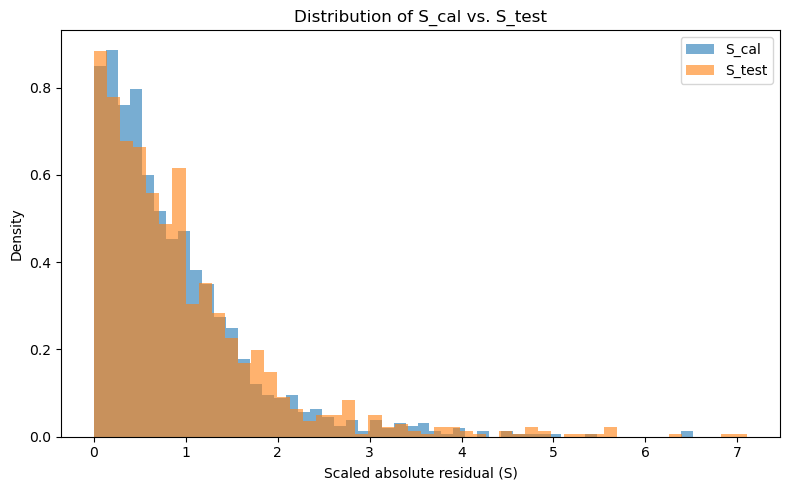

In [27]:
S_cal = np.abs(Y_cal_true - Y_cal_fit) / sigma_cal
S_test = np.abs(Y_test_true - Y_test_fit) / sigma_test
plt.figure(figsize=(8,5))
plt.hist(S_cal, bins=50, alpha=0.6, density=True, label='S_cal')
plt.hist(S_test, bins=50, alpha=0.6, density=True, label='S_test')
plt.xlabel("Scaled absolute residual (S)")
plt.ylabel("Density")
plt.title("Distribution of S_cal vs. S_test")
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
np.quantile(S_cal, 0.9, method="higher")

1.8432678472205384

In [31]:
np.quantile(S_test, 0.9, method="higher")

1.979624537097104

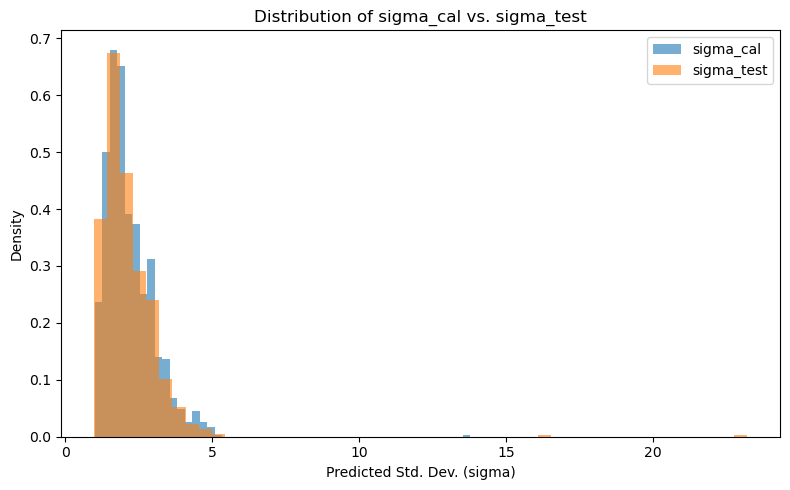

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(sigma_cal, bins=50, alpha=0.6, label="sigma_cal", color='C0', density=True)
plt.hist(sigma_test, bins=50, alpha=0.6, label="sigma_test", color='C1', density=True)
plt.xlabel("Predicted Std. Dev. (sigma)")
plt.ylabel("Density")
plt.title("Distribution of sigma_cal vs. sigma_test")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
covered = (Y_test_true >= tmfv_result[0]) & (Y_test_true <= tmfv_result[1])
cov = float(np.mean(covered)) if covered.size > 0 else float("nan")

In [25]:
cov

0.8834170854271357

In [7]:
# --- 4) Conformal calibration and prediction ---
cp = NaiveAbsoluteResidualCP(shape_ref=Y, J=J, alpha=0.1)
cp.calibrate_from_fit(cal_idx, Y_cal_true, Y_cal_fit)
intervals = cp.predict_interval_from_fit(test_idx, Y_test_fit, alpha=0.1)

# --- 5) Evaluate coverage on masked entries ---
lower = intervals[:, 0]
upper = intervals[:, 1]
covered = (Y_test_true >= lower) & (Y_test_true <= upper)
cov = float(np.mean(covered)) if covered.size > 0 else float("nan")

In [10]:
# overall
cov_all, n_all = conditional_coverage(test_idx, covered, I, J, T)

# subject 0 only
cov_s0, n_s0 = conditional_coverage(test_idx, covered, I, J, T, subjects=[0])

# channels 0,2,4 only
cov_ch, n_ch = conditional_coverage(test_idx, covered, I, J, T, channels=[0,2,4])

# time window t=20..40 only
cov_t, n_t = conditional_coverage(test_idx, covered, I, J, T, t_range=(20,40))

# subject 0, channel 3, time 50..80
cov_cond, n_cond = conditional_coverage(
    test_idx, covered, I, J, T, subjects=[0], channels=[3], t_range=(50,80)
)

print(cov_cond, n_cond)

1.0 11


In [13]:
cov_ch

0.9195979899497487

In [28]:
cp = NaiveAbsoluteResidualCP(shape_ref=Y, J=J, alpha=0.1)
cp.calibrate_from_fit(cal_idx, Y_cal_true, Y_cal_fit)

In [ ]:
cp['alpha']

In [6]:
import torch

# Unpack results as per your tuple: L, a2, psi, s, C, u_tilde, F_tilde, history
L = em_result[0]       # shape (J, r)
a2 = em_result[1]      # shape (I, T, r)
psi = em_result[2]     # shape (J,)
s = em_result[3]       # shape (I,)

# Calculate factor_part: shape (I, T, J)
# factor_part[i, t, j] = sum_k L[j, k]**2 * a2[i, t, k]
factor_part = torch.einsum('itr,jr->itj', a2, L.pow(2))

# Calculate noise_part: shape (I, J)
# noise_part[i, j] = s[i]**2 * psi[j]
noise_part = (s**2)[:, None] * psi[None, :]


In [13]:
noise_part[0,0]

tensor(1.4676, device='cuda:0', grad_fn=<SelectBackward0>)

In [10]:
factor_part[0,:,0]

tensor([ 0.1288,  0.1288,  0.1398,  0.1415,  0.1425,  0.1470,  0.1596,  0.1609,
         0.1623,  0.1666,  0.1683,  0.1797,  0.1842,  0.1847,  0.1855,  0.1860,
         0.1861,  0.1909,  0.1959,  0.1987,  0.2274,  6.1146, 14.5162, 14.5202,
        11.5794, 11.2255, 11.2247, 11.7583, 12.3840, 12.3650, 12.6377, 13.1145,
        13.1185, 10.8740,  2.9596,  2.3434,  2.2305,  2.2197,  2.2243,  2.1709,
         2.1257,  2.0022,  1.9935,  1.9729,  1.9674,  1.9274,  1.9460,  1.9937,
         1.9841,  1.9907,  1.9865,  1.9823,  2.0366,  2.1619,  2.2098,  2.2277,
         2.3178,  2.3796,  2.7506,  2.8025,  2.8257,  3.1192,  3.4125,  3.8263,
         4.0477,  4.0464,  4.0768,  4.0940,  4.0891,  4.0722,  4.0725,  4.1991,
         4.2615,  4.2708,  4.2752,  4.2727,  4.2155,  4.1921,  4.1924,  4.1849,
         4.1779,  4.2025,  4.2083,  4.2056,  4.2100,  4.2314,  4.2431,  4.3674,
         4.4088,  4.7517,  4.8571,  5.3622,  5.4645,  5.5310,  6.3527,  6.3817,
         5.9574,  7.0733,  7.4890,  7.47

In [6]:
em_result[4][0,:,:]

tensor([[1.0854e-05, 8.9272e-05],
        [1.6101e-05, 8.9281e-05],
        [1.1439e-03, 2.5001e-04],
        [1.3453e-03, 2.5017e-04],
        [1.4553e-03, 2.5149e-04],
        [1.8316e-03, 3.6289e-04],
        [3.0346e-03, 4.3717e-04],
        [3.1365e-03, 4.5812e-04],
        [3.2398e-03, 5.2189e-04],
        [3.6346e-03, 5.2357e-04],
        [3.7029e-03, 6.5229e-04],
        [4.5435e-03, 9.9671e-04],
        [4.8853e-03, 1.0236e-03],
        [4.9246e-03, 1.0252e-03],
        [4.9895e-03, 1.0256e-03],
        [4.9900e-03, 1.0999e-03],
        [4.9925e-03, 1.1126e-03],
        [5.3363e-03, 1.1860e-03],
        [5.7070e-03, 1.2039e-03],
        [5.8497e-03, 1.3304e-03],
        [7.6732e-03, 1.5937e-03],
        [6.0368e-02, 2.2893e-03],
        [1.1925e-01, 2.4083e-03],
        [1.2068e-01, 2.5986e-03],
        [2.3951e-01, 2.9234e-03],
        [2.8019e-01, 2.9235e-03],
        [2.9441e-01, 3.3092e-03],
        [3.5659e-01, 3.3833e-03],
        [5.1603e-01, 5.3689e-03],
        [5.409

In [16]:
import torch
from twfv.variance import build_a2_from_C_and_warp

def local_var_from_fit(L, a2, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)

In [17]:
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], em_result[5], knots, degree).cpu().numpy()

1.596313 15.987721
1.9324163 19.038786
1.7261679 18.308601
1.7303684 12.091889
1.0735306 7.38124


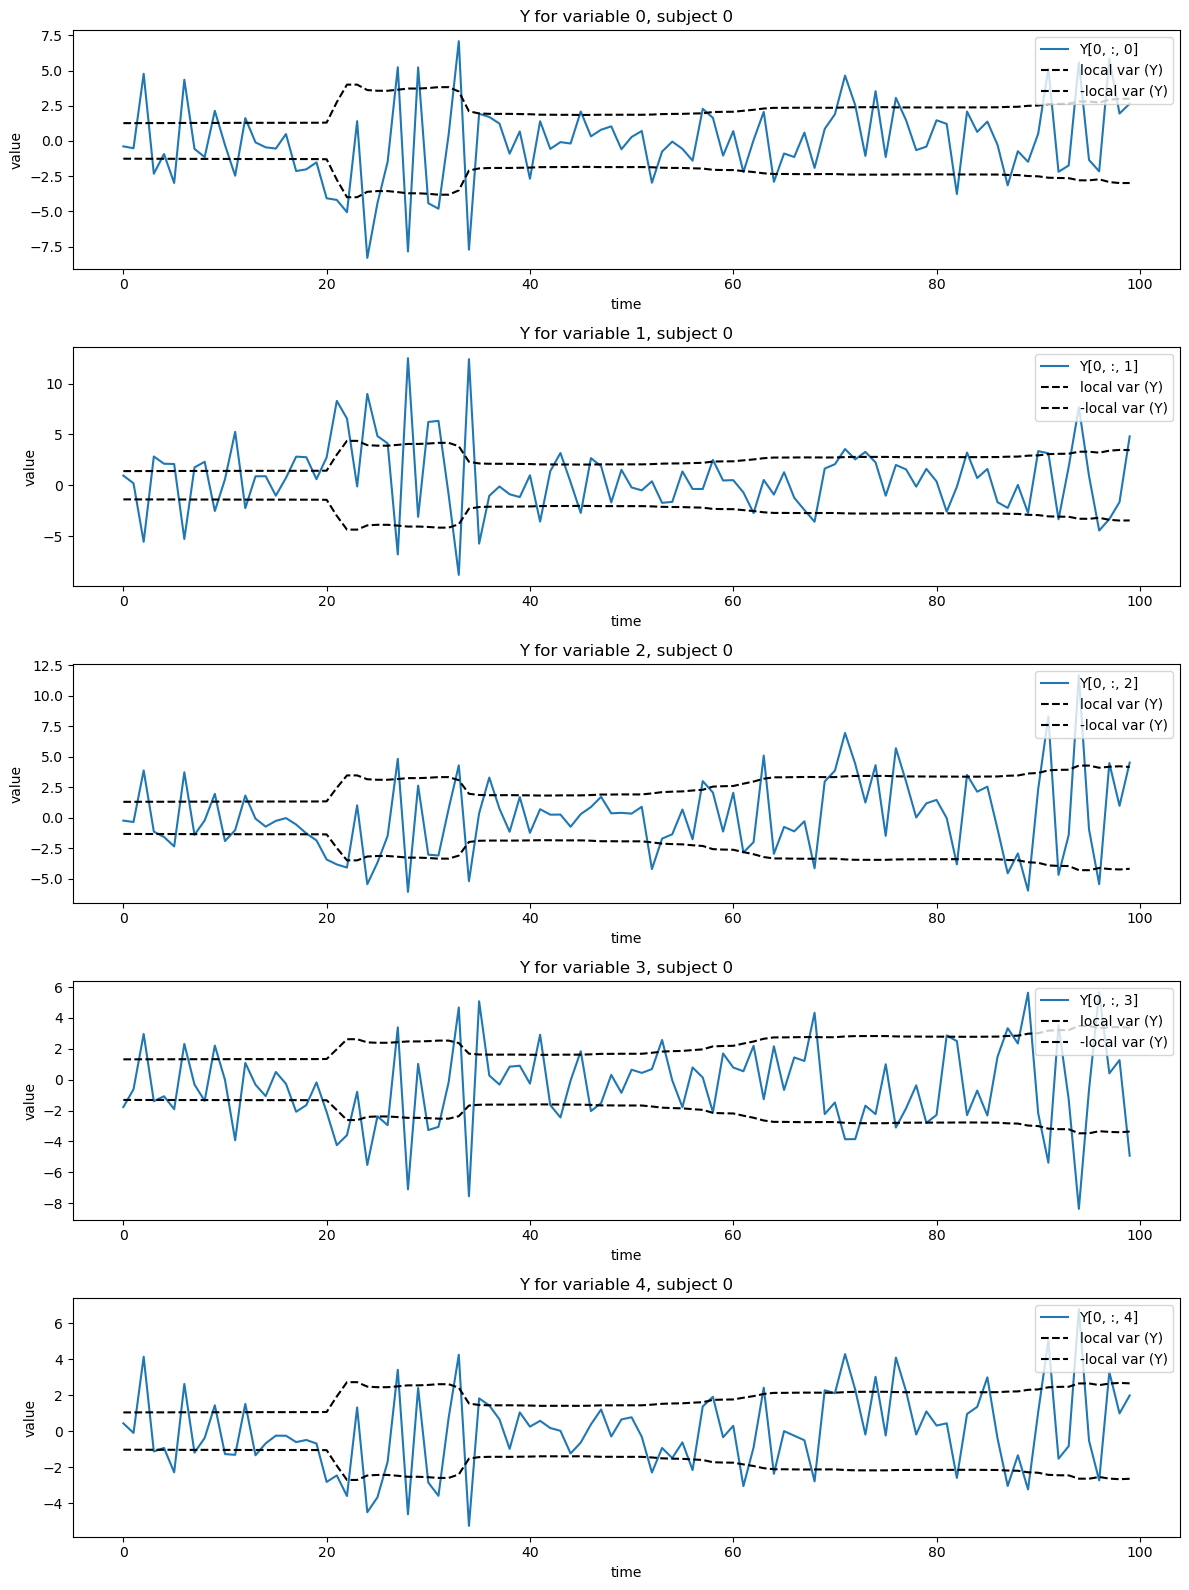

In [20]:
import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_fitted[0, :, j]  # shape (T,)
    print(var.min(),var.max())
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

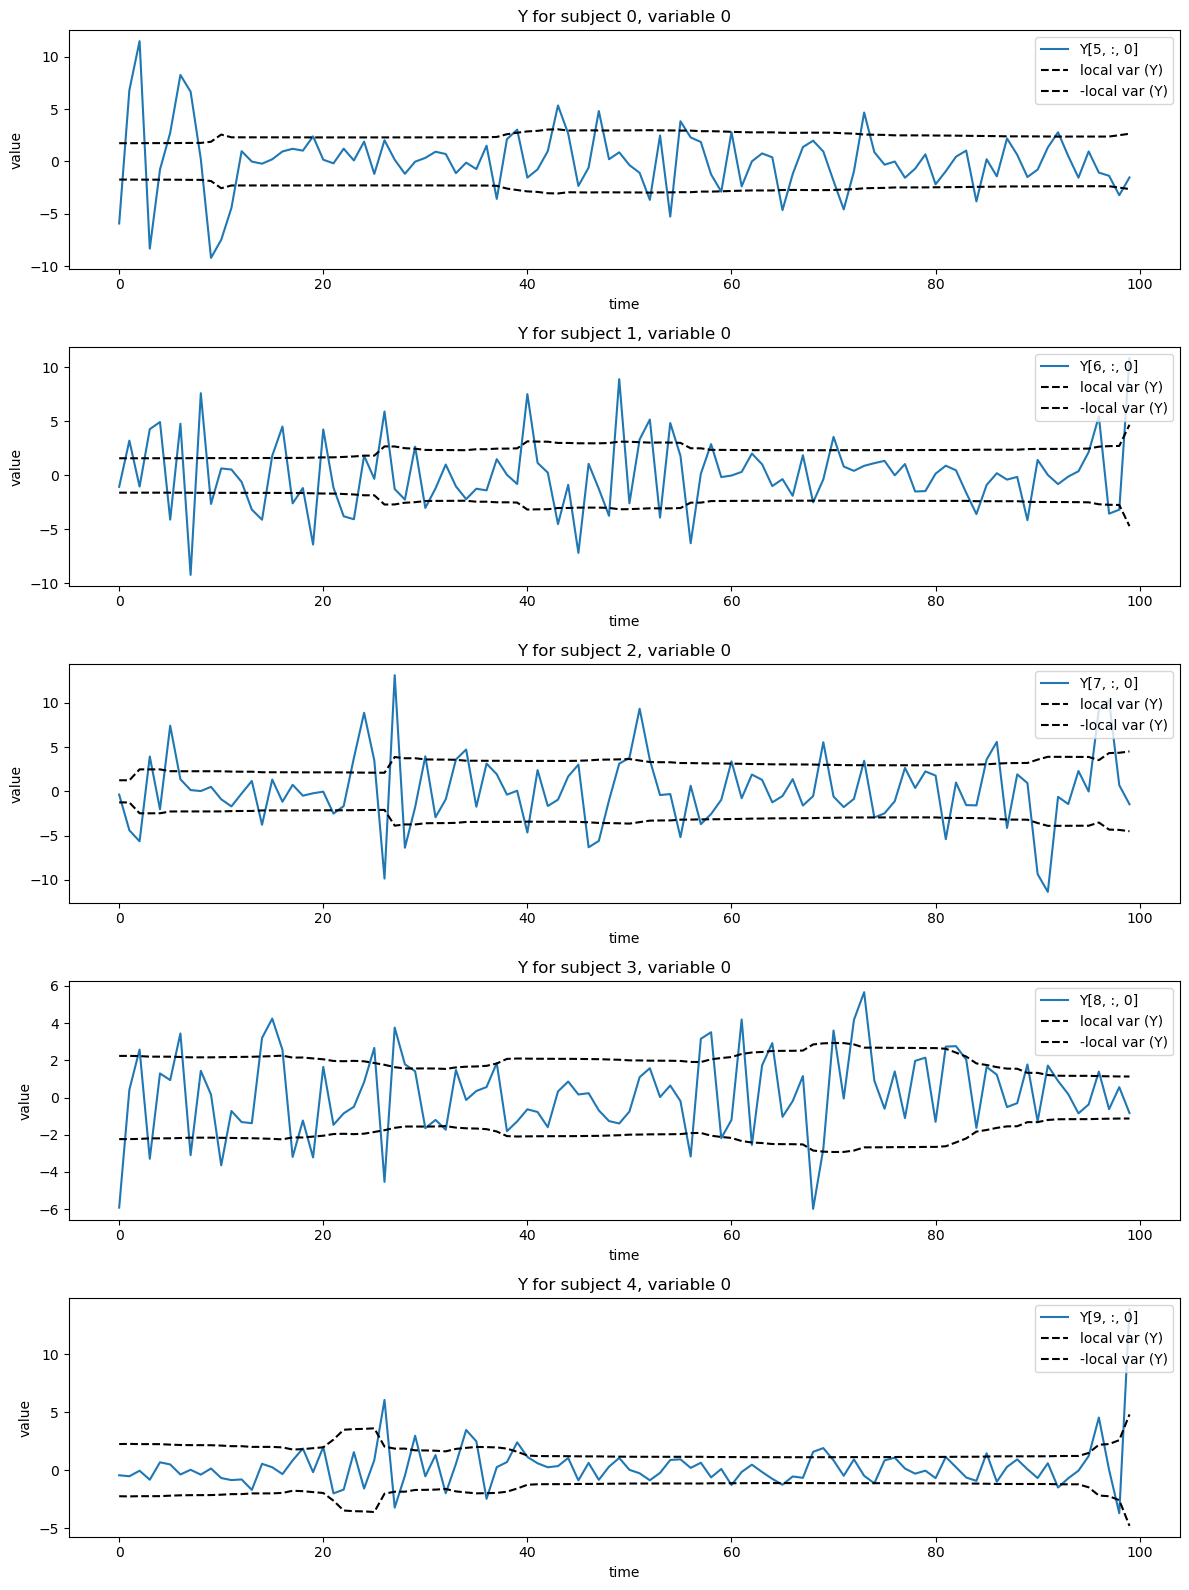

In [22]:

import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
incre=5
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i+incre, :, 0], label=f"Y[{i+incre}, :, 0]")
    var = local_var_fitted[i+incre, :, 0]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for subject {i}, variable 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()
